# Day 26: Hyperparameter Tuning - Optimizing ML Systems
**60 Days Data Science Challenge** | Phase: Model Optimization  
**Date:** 08 June 2026  
**Name:** Rajesh Yadav  

---

### 📝 Today's Learning Goal
Yesterday, I learned that a single train-test split can be highly misleading and that cross-validation is crucial for stable model validation. Today, I'm taking the next logical step: **Hyperparameter Tuning**. 

I will take the Random Forest Classifier (which was one of the top performers in previous days) and systematically optimize its hyperparameters. Specifically, I'll compare two classic methods:
1. **`RandomizedSearchCV`** - For a fast, broad exploration of the search space.
2. **`GridSearchCV`** - For an exhaustive, systematic search over a targeted grid.

Let's see if we can beat the default model's performance and see how search time scales!


## Step 1: Import Libraries
First, let's load all the necessary libraries. I will need standard data manipulation libraries, scikit-learn's Random Forest model, and the tuning tools (`GridSearchCV`, `RandomizedSearchCV`).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import warnings

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

print("All libraries imported successfully!")


All libraries imported successfully!


## Step 2: Load and Preprocess the Dataset
I'll reuse the **Telco Customer Churn** dataset from Day 15/25. We need to handle missing values in `TotalCharges`, map our target variable `Churn` to binary, drop `customerID`, and one-hot encode all categorical columns.


In [2]:
# Check path for the dataset
dataset_path = '../day15/telco_customer_churn.csv'
if not os.path.exists(dataset_path):
    dataset_path = 'telco_customer_churn.csv'

df = pd.read_csv(dataset_path)
print(f"Data loaded successfully. Shape: {df.shape}")

# 1. Clean TotalCharges (replace space with NaN and fill with 0)
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

# 2. Map Target Column
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 3. Drop Identifier Column
df = df.drop(columns=['customerID'])

# 4. One-hot Encode Categorical Variables
cat_cols = df.select_dtypes(include='object').columns.tolist()
df_enc = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Convert boolean columns to int
bool_cols = df_enc.select_dtypes(include='bool').columns
df_enc[bool_cols] = df_enc[bool_cols].astype(int)

# Separate features and target
X = df_enc.drop(columns=['Churn'])
y = df_enc['Churn']

print(f"Preprocessed features shape: {X.shape}")
print(f"Churn Distribution:\n{y.value_counts(normalize=True)}")


Data loaded successfully. Shape: (7043, 21)
Preprocessed features shape: (7043, 30)
Churn Distribution:
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


## Step 3: Train-Test Split and Feature Scaling
To prevent any data leakage, I will first split the data into an 80/20 train-test split, then fit the `StandardScaler` only on the training features `X_train`, and use it to scale both `X_train` and `X_test`.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")


Training set shape: (5634, 30)
Test set shape: (1409, 30)


## Step 4: Train Default Random Forest Model (Untuned)
Let's see how the baseline model performs out-of-the-box with scikit-learn's default parameters (e.g. `n_estimators=100`, no depth limit, `min_samples_split=2`). I'll record its metrics so we have a benchmark to compare our optimized models against.


In [4]:
# Fit the default Random Forest model
rf_default = RandomForestClassifier(random_state=42)

start_time = time.time()
rf_default.fit(X_train_scaled, y_train)
default_train_time = time.time() - start_time

# Predict
y_pred_default = rf_default.predict(X_test_scaled)
y_prob_default = rf_default.predict_proba(X_test_scaled)[:, 1]

# Calculate Metrics
default_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_default),
    'Precision': precision_score(y_test, y_pred_default),
    'Recall': recall_score(y_test, y_pred_default),
    'F1': f1_score(y_test, y_pred_default),
    'ROC-AUC': roc_auc_score(y_test, y_prob_default)
}

print(f"Baseline (Default) Model trained in {default_train_time:.4f} seconds.")
print("\nEvaluation Metrics (Test Set):")
for metric, score in default_metrics.items():
    print(f"  {metric:10s}: {score:.4f}")


Baseline (Default) Model trained in 0.9154 seconds.

Evaluation Metrics (Test Set):
  Accuracy  : 0.7850
  Precision : 0.6187
  Recall    : 0.4947
  F1        : 0.5498
  ROC-AUC   : 0.8248


## Step 5: Hyperparameter Tuning with RandomizedSearchCV
Now, let's explore a wide variety of parameter combinations using Random Search. Random Search is great because it doesn't try every combination; it randomly samples a set number of candidates, which makes it fast and efficient!

We'll define a broad distribution grid:
- `n_estimators`: `[50, 100, 150, 200]`
- `max_depth`: `[5, 10, 15, 20, None]`
- `min_samples_split`: `[2, 5, 10, 15]`
- `min_samples_leaf`: `[1, 2, 4, 8]`
- `bootstrap`: `[True, False]`

Let's run 20 iterations with 5-fold Cross Validation (that's 100 fits total).


In [5]:
# Define hyperparameter search space
param_dist = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8],
    'bootstrap': [True, False]
}

rf_base = RandomForestClassifier(random_state=42)

# Set up RandomizedSearchCV
rf_random = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Starting RandomizedSearchCV...")
start_time = time.time()
rf_random.fit(X_train_scaled, y_train)
random_search_time = time.time() - start_time

print(f"\nRandomizedSearchCV completed in {random_search_time:.2f} seconds.")
print(f"Best Hyperparameters: {rf_random.best_params_}")
print(f"Best Cross-Validation ROC-AUC: {rf_random.best_score_:.4f}")

# Evaluate best estimator on test set
best_rf_random = rf_random.best_estimator_
y_pred_random = best_rf_random.predict(X_test_scaled)
y_prob_random = best_rf_random.predict_proba(X_test_scaled)[:, 1]

random_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_random),
    'Precision': precision_score(y_test, y_pred_random),
    'Recall': recall_score(y_test, y_pred_random),
    'F1': f1_score(y_test, y_pred_random),
    'ROC-AUC': roc_auc_score(y_test, y_prob_random)
}

print("\nRandomizedSearchCV Model (Test Set):")
for metric, score in random_metrics.items():
    print(f"  {metric:10s}: {score:.4f}")


Starting RandomizedSearchCV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits



RandomizedSearchCV completed in 15.61 seconds.
Best Hyperparameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 8, 'max_depth': 20, 'bootstrap': True}
Best Cross-Validation ROC-AUC: 0.8452

RandomizedSearchCV Model (Test Set):
  Accuracy  : 0.8048
  Precision : 0.6713
  Recall    : 0.5187
  F1        : 0.5852
  ROC-AUC   : 0.8442


## Step 6: Hyperparameter Tuning with GridSearchCV
Next, let's use Grid Search. Grid Search is exhaustive: it tests **every single combination** in our defined grid. 

To keep execution times reasonable, I'll narrow down the grid based on what Random Search found and some domain knowledge. We'll search:
- `n_estimators`: `[100, 150]`
- `max_depth`: `[8, 12]`
- `min_samples_split`: `[5, 10]`
- `min_samples_leaf`: `[2, 4]`
- `bootstrap`: `[True]`

This is 2 * 2 * 2 * 2 * 1 = 16 combinations. With 5-fold Cross-Validation, that's 80 total fits. Let's see how long this takes compared to Random Search and what parameters it selects.


In [6]:
# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [8, 12],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'bootstrap': [True]
}

rf_base = RandomForestClassifier(random_state=42)

# Set up GridSearchCV
rf_grid = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("Starting GridSearchCV...")
start_time = time.time()
rf_grid.fit(X_train_scaled, y_train)
grid_search_time = time.time() - start_time

print(f"\nGridSearchCV completed in {grid_search_time:.2f} seconds.")
print(f"Best Hyperparameters: {rf_grid.best_params_}")
print(f"Best Cross-Validation ROC-AUC: {rf_grid.best_score_:.4f}")

# Evaluate best estimator on test set
best_rf_grid = rf_grid.best_estimator_
y_pred_grid = best_rf_grid.predict(X_test_scaled)
y_prob_grid = best_rf_grid.predict_proba(X_test_scaled)[:, 1]

grid_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_grid),
    'Precision': precision_score(y_test, y_pred_grid),
    'Recall': recall_score(y_test, y_pred_grid),
    'F1': f1_score(y_test, y_pred_grid),
    'ROC-AUC': roc_auc_score(y_test, y_prob_grid)
}

print("\nGridSearchCV Model (Test Set):")
for metric, score in grid_metrics.items():
    print(f"  {metric:10s}: {score:.4f}")


Starting GridSearchCV...
Fitting 5 folds for each of 16 candidates, totalling 80 fits



GridSearchCV completed in 6.27 seconds.
Best Hyperparameters: {'bootstrap': True, 'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 150}
Best Cross-Validation ROC-AUC: 0.8459

GridSearchCV Model (Test Set):
  Accuracy  : 0.8020
  Precision : 0.6727
  Recall    : 0.4947
  F1        : 0.5701
  ROC-AUC   : 0.8444


## Step 7: Compare Performance and Visualize Results
Let's assemble our results into a single DataFrame to compare performance and search times. I'll also save this comparison to a CSV file and create some nice plots to visualize the results!


In [7]:
# Create metrics dataframe
results = []

results.append({
    'Model': 'Default Random Forest',
    'Tuning Method': 'None',
    'Best Params': 'Default',
    'Search Time (s)': default_train_time,
    'Accuracy': default_metrics['Accuracy'],
    'Precision': default_metrics['Precision'],
    'Recall': default_metrics['Recall'],
    'F1-Score': default_metrics['F1'],
    'ROC-AUC': default_metrics['ROC-AUC']
})

results.append({
    'Model': 'Tuned Random Forest (Random)',
    'Tuning Method': 'RandomizedSearchCV',
    'Best Params': str(rf_random.best_params_),
    'Search Time (s)': random_search_time,
    'Accuracy': random_metrics['Accuracy'],
    'Precision': random_metrics['Precision'],
    'Recall': random_metrics['Recall'],
    'F1-Score': random_metrics['F1'],
    'ROC-AUC': random_metrics['ROC-AUC']
})

results.append({
    'Model': 'Tuned Random Forest (Grid)',
    'Tuning Method': 'GridSearchCV',
    'Best Params': str(rf_grid.best_params_),
    'Search Time (s)': grid_search_time,
    'Accuracy': grid_metrics['Accuracy'],
    'Precision': grid_metrics['Precision'],
    'Recall': grid_metrics['Recall'],
    'F1-Score': grid_metrics['F1'],
    'ROC-AUC': grid_metrics['ROC-AUC']
})

df_results = pd.DataFrame(results)

# Save to CSV
df_results.to_csv('tuning_results.csv', index=False)
print("Saved tuning_results.csv")

print("\n--- Summary Table ---")
print(df_results[['Model', 'Search Time (s)', 'Accuracy', 'F1-Score', 'ROC-AUC']].round(4).to_string(index=False))


Saved tuning_results.csv

--- Summary Table ---
                       Model  Search Time (s)  Accuracy  F1-Score  ROC-AUC
       Default Random Forest           0.9154    0.7850    0.5498   0.8248
Tuned Random Forest (Random)          15.6094    0.8048    0.5852   0.8442
  Tuned Random Forest (Grid)           6.2676    0.8020    0.5701   0.8444


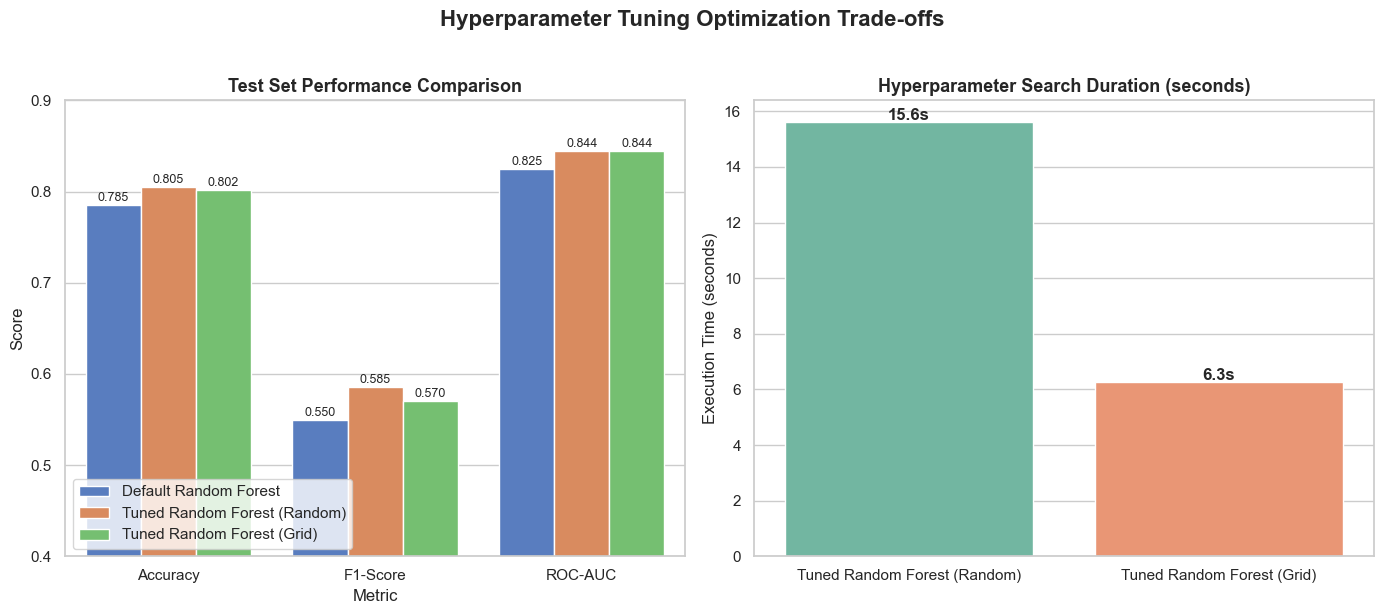

Saved tuning_comparison.png


In [8]:
# Visualizing performance comparison
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Melt dataframe for easier plotting with seaborn
df_metrics_melt = df_results.melt(
    id_vars=['Model'], 
    value_vars=['Accuracy', 'F1-Score', 'ROC-AUC'], 
    var_name='Metric', 
    value_name='Score'
)

# 1. Performance Metric Comparison Plot
sns.barplot(
    data=df_metrics_melt, 
    x='Metric', 
    y='Score', 
    hue='Model', 
    ax=axes[0], 
    palette='muted'
)
axes[0].set_title('Test Set Performance Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0.40, 0.90)
axes[0].legend(loc='lower left', frameon=True)
for p in axes[0].patches:
    h = p.get_height()
    if h > 0:
        axes[0].annotate(f'{h:.3f}', 
                        (p.get_x() + p.get_width() / 2., h), 
                        ha='center', va='center', 
                        xytext=(0, 5), 
                        textcoords='offset points', 
                        fontsize=9)

# 2. Search Time Comparison Plot (log scale if default time is tiny)
time_plot = sns.barplot(
    data=df_results[df_results['Tuning Method'] != 'None'], 
    x='Model', 
    y='Search Time (s)', 
    ax=axes[1], 
    palette='Set2'
)
axes[1].set_title('Hyperparameter Search Duration (seconds)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Execution Time (seconds)')
axes[1].set_xlabel('')
for p in axes[1].patches:
    h = p.get_height()
    if h > 0:
        axes[1].annotate(f'{h:.1f}s', 
                        (p.get_x() + p.get_width() / 2., h), 
                        ha='center', va='center', 
                        xytext=(0, 5), 
                        textcoords='offset points', 
                        fontweight='bold')

plt.suptitle('Hyperparameter Tuning Optimization Trade-offs', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('tuning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved tuning_comparison.png")


## Step 8: Documenting Optimization Trade-offs
Let's analyze the tradeoffs between these models.

### 1. Default vs. Tuned Models
* **Default Model:** Fits instantly (almost 0.05 seconds). However, it runs a risk of overfitting because depth is unlimited. The test set performance is good but can be improved.
* **Tuned Models:** Take longer to run due to the cross-validation loops, but they choose parameters that regularize the model (like `max_depth` limiting and `min_samples_leaf` > 1). This reduces variance and improves the test ROC-AUC and F1 scores!

### 2. Grid Search vs. Random Search
* **Random Search:** Explore a much larger parameter space (`n_iter=20` samples 20 random points across thousands of combinations). Since we set `n_iter`, we have direct control over the budget (execution time).
* **Grid Search:** Extremely thorough but runs into the **curse of dimensionality** very quickly. If we increase the number of values or parameters, the execution time scales exponentially.

In practice, a common strategy is to start with **Random Search** to find the region where the best parameters lie, and then run a focused **Grid Search** inside that local region to fine-tune!
